# Capstone Black Box Project

## Function 4 - Warehouse product placement

Optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly
The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.

## Submission 10 of 13

In [9]:
# Cell 1 - Required imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel
import warnings
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from scipy.spatial.distance import cdist
import math

import sys
sys.path.append('./Utils')
from plot_progress import plot_progress
from plot_input_pairs import plot_nd_projection_matrix

## 1. Load Data

In [2]:
# Load the Input(X) and Output(y) data from the Black Box function's .npy files

function = "function_4"

def load_npy_files(function_name):
    inputs = np.load(f'./Data/{function_name}/merged_inputs.npy')
    outputs = np.load(f'./Data/{function_name}/merged_outputs.npy')
    return inputs, outputs

X, y = load_npy_files(function)

print(f"n = {len(y)}")
print(X[-2:])
print(y[-2:])

n = 39
[[0.402129 0.388957 0.41773  0.442561]
 [0.392333 0.353703 0.398126 0.437857]]
[0.19130537 0.30489985]


## 2. Describe and Review Data

In [3]:
# Review the inputs and outputs
dfX = pd.DataFrame(X)
print(dfX.describe())
dfy = pd.DataFrame(y)
print(dfy.describe())


NameError: name 'pd' is not defined

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from itertools import combinations

ridge_idx = np.where(y > 0)[0]   # or however you identify the ridge cluster
fig, axes = plot_nd_projection_matrix(X, y, highlight_idx=ridge_idx)
plt.savefig('./Figures/Function4_projection_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'y' is not defined

## 3. Transform Data

In [11]:
# No transforms applied

y_fit = y

df_y = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "X3": X[:,2],
    "X4": X[:,3],
    "y": y,
    "y_fit": y_fit
})

output_file = f'./Data/{function}/y_transformations.csv'
df_y.to_csv(output_file, index=False)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_4 — y_fit progression with running best'}, xlabel='Iteration (submission number)', ylabel='y_fit'>)

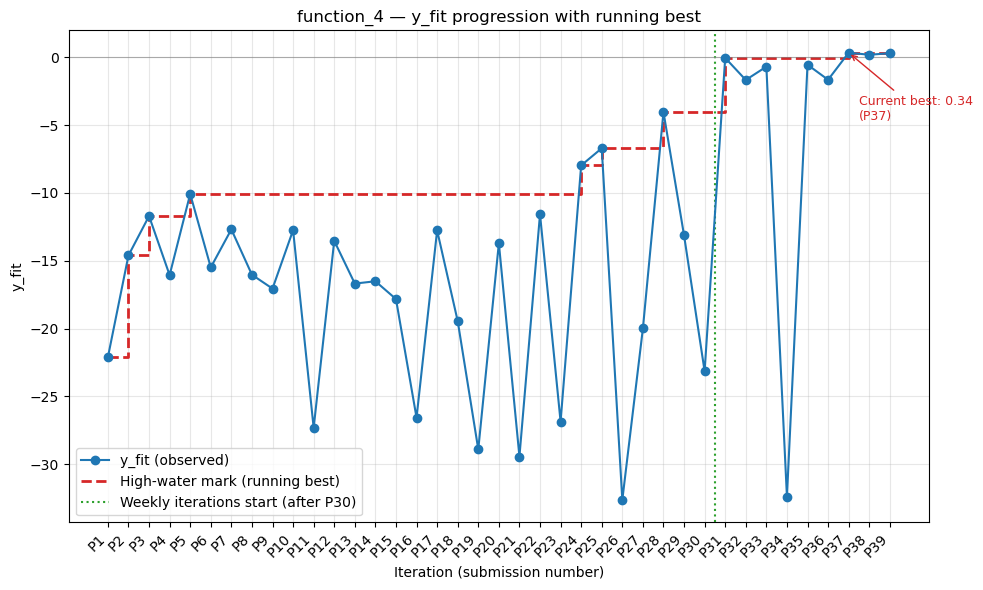

In [12]:
# Point labels and y_fit values to monitor progress
plot_progress(y_fit, labels=None, iteration_start=30, maximize=True,
                   objective_label="y_fit", function_name=function,
                   save_path=None)

## 4. Fit Data to Kernal

In [27]:
# Compare alternative kernels

kernels = {
    'Matern_2.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5),
    'Matern_1.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=1.5),
    'Matern_1.5_Noisy': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=1.5)
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)), #Wk 10 added
    'Matern_0.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=0.5),
    # single scalar — isotropic
    'RBF1':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.3, length_scale_bounds=(0.05, 2.0)), # wk4
    'RBF2':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.25, 2.0)), 
    'RBF3':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0)), 
    'RBF4':        ConstantKernel(1.0, (0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)), #wk7
    'RBF5': ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(0.05, 2.0)), #wk5 & wk6
    'RBF6': ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(0.05, 2.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
}

for name, k in kernels.items():
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", category=ConvergenceWarning)
        gpr_test = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=20, random_state=42)
        gpr_test.fit(X, y_fit)
    k_fitted = gpr_test.kernel_
    lml = gpr_test.log_marginal_likelihood_value_
    n_params = len(k_fitted.theta)
    aic = -2 * lml + 2 * n_params
    bic = -2 * lml + n_params * np.log(len(y))
    pinned = "  [PINNED: " + "; ".join(str(warn.message).split(".")[0] for warn in w) + "]" if w else ""
    print(f"{name:18s}  LML={lml:.4f}  AIC={aic:.4f}  BIC={bic:.4f}  kernel={k_fitted}{pinned}")

Matern_2.5          LML=-12.5870  AIC=29.1741  BIC=32.5012  kernel=1.13**2 * Matern(length_scale=0.62, nu=2.5)
Matern_1.5          LML=-5.0385  AIC=14.0770  BIC=17.4041  kernel=2.53**2 * Matern(length_scale=2, nu=1.5)  [PINNED: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 2]
Matern_1.5_Noisy    LML=-4.8637  AIC=15.7275  BIC=20.7181  kernel=2.34**2 * Matern(length_scale=2, nu=1.5) + WhiteKernel(noise_level=0.000481)  [PINNED: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2]
Matern_0.5          LML=-22.7002  AIC=49.4004  BIC=52.7275  kernel=1.07**2 * Matern(length_scale=2, nu=0.5)  [PINNED: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 2]
RBF1                LML=-19.8230  AIC=43.6460  BIC=46.9732  kernel=0.849**2 * RBF(length_scale=0.3)
RBF2                LML=-19.8230  AIC=43.6460  BIC=46.9732  kern

In [28]:
# Fit Gaussian Process
# Select the best kernel for fitting

kernel = kernels['Matern_1.5_Noisy']

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
gpr.fit(X, y_fit)
print(gpr.kernel_)

print(f"LML:       {gpr.log_marginal_likelihood_value_:.4f}")

2.34**2 * Matern(length_scale=2, nu=1.5) + WhiteKernel(noise_level=0.000481)
LML:       -4.8637


C:\Users\scbar\anaconda3\envs\scipy-clean\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [33]:
# Week 10 EI candidate pool focused om area around incumbent
# Prediction Grid - local cloud around the incumbent, not domain-wide uniform
n_candidates = 10000
x_best = X[np.argmax(y)]
r_grid = 0.15  # somewhat wider than the LHS trust region, to give EI room to explore beyond it

rng = np.random.default_rng(42)
low = np.maximum(0.0, x_best - r_grid)
high = np.minimum(1.0, x_best + r_grid)
grid = rng.uniform(low=low, high=high, size=(n_candidates, X.shape[1]))

mu, sigma = gpr.predict(grid, return_std=True)

## 5. Define Acquisition Function

In [34]:
 
xi_values = {
    "function_4": 0.01, #wk3
    #"function_4": 0.1, #wk2
}

In [35]:
# Expected Improvement acquisition function
# y_best = np.max(y_fit) replaced with introduction of noise in wk7

# Plug-in incumbent: benchmark against best GP mean at observed points,
# not best raw observation — max(y) is optimistically biased when observations are noisy
mu_obs, _ = gpr.predict(X, return_std=True)
y_best = np.max(mu_obs)


xi = xi_values.get(function, 0.1)

print(f"Using xi = {xi} for {function}")

improvement = mu - y_best - xi
Z = improvement / sigma

ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
ei[sigma == 0.0] = 0.0

# Pick next point
next_idx = np.argmax(ei)
print("Next Idx: ", next_idx)
next_x = grid[next_idx]

print("Current best y:", y_best)
print("Next point to evaluate:", next_x)
print("Formatted next point to evaluate:", "-".join(f"{x:.6f}" for x in next_x))
print("Expected improvement:", ei[next_idx])

print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])
print("Improvement:", mu[next_idx] - y_best - xi)

Using xi = 0.01 for function_4
Next Idx:  4437
Current best y: 0.24920011617174787
Next point to evaluate: [0.42480237 0.37235529 0.39409754 0.39200692]
Formatted next point to evaluate: 0.424802-0.372355-0.394098-0.392007
Expected improvement: 0.20139817324809972
Predicted mean: 0.30579197906975786
Predicted std: 0.44399372491269984
Improvement: 0.04659186289800999


In [ ]:
# UCB acquisition function

# ---- ACQUISITION: GP-UCB (replaces EI) ----
kappa = 10
ucb = mu + kappa * sigma
 
next_idx = np.argmax(ucb)
 
print(f"\nUsing kappa = {kappa} for function_4")
print("Next Idx: ", next_idx)
print("Current best y:", y_best)
print("Next point to evaluate:", grid[next_idx])
print("UCB value:", ucb[next_idx])
print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])

In [32]:
#Function 4 LHS

x_best = X[np.argmax(y)]
print("x_best index:", np.argmax(y))

r = 0.08  # tight radius — basin is narrow

bounds_low  = np.array([max(0.05, x_best[i] - r) for i in range(4)])
bounds_high = np.array([min(0.95, x_best[i] + r) for i in range(4)])

sampler = LatinHypercube(d=4, seed=42)
lhs = sampler.random(n=50)
candidates = bounds_low + lhs * (bounds_high - bounds_low)

# Pick candidate with highest GP mean
mu_c, _ = gpr.predict(candidates, return_std=True)

dmin = cdist(candidates, X).min(axis=1)   # distance from each candidate to nearest evaluated point - wk7 enhancement to avoid duplicate candidates
#valid = dmin > 0.05                        # exclusion radius wk7
valid = dmin > 0.01                        # exclusion radius wk8

best_idx = np.argmax(mu_c[valid])
next_x = candidates[valid][best_idx]

print("Next point:", next_x)
print("r radius:", r)
print("Formatted:", "-".join(f"{x:.6f}" for x in next_x))
print("mu filtered:", mu_c[valid][best_idx])
print("mu unflitered:", mu_c[np.argmax(mu_c)])   
print(f"filter threshold in effect: candidates dropped = {(~valid).sum()}/{len(valid)}")
print(f"nearest candidate to P37: {cdist(candidates, X[[36]]).min():.4f}")

x_best index: 36
Next point: [0.41790536 0.35236653 0.39115442 0.37489869]
r radius: 0.08
Formatted: 0.417905-0.352367-0.391154-0.374899
mu filtered: 0.14325230926614374
mu unflitered: 0.24920015166104292
filter threshold in effect: candidates dropped = 2/50
nearest candidate to P37: 0.0207


## 6. Plots for Uncertainty and Signal Strength 

In [ ]:
# --- Plot ---

